This jupyter notebook contains code for generating the following of the Zhou et al. 2024 paper
- the LaTex code for Table 1;
- Figure 5 (the main IFE figure for Concatenation mode);

For the Latex code: it reads the IFE_unified.csv file that contains the {slope, intercept, $R^2$, RMSE} information of each condition for all models, and convert the dataframe to the code for TeX table.

For the Figure, due to the need to customize the display of "slope, intercept, and $R^2$ texts on the plot, we manually coded the position the texts are displayed on each plot, resulting in a long code cell for it.

In [1]:
import csv
import pandas as pd
from utils import *

# Combining into a big dataframe

In [6]:
# result = pd.DataFrame()  # create an empty DataFrame
# # Loop through the DataFrame list and concatenate
# for MODEL in ['GPT2', 'Llama', 'GPT3']:
#     input_path = f'{ROOT_DIR}/results/{MODEL}/IFE_{MODEL}_Stats.csv'
#     df = pd.read_csv(input_path)
#     df['size'] = MODEL + '-' + df['size']
#     result = pd.concat([result, df], ignore_index=True)

# result.to_csv(f'{ROOT_DIR}/results/IFE_all.csv', index=False)


# LaTex Code for Main Table

In [25]:
df = pd.read_csv(f'{ROOT_DIR}/results/IFE_all.csv')
df[['size', 'pronoun', 'PD-PD_p_value', 'DO-PD_p_value']]

,size,pronoun,PD-PD_p_value,DO-PD_p_value
0,GPT2-small,True,0.596899,6.975455e-01
1,GPT2-small,False,0.495142,7.978158e-01
2,GPT2-medium,True,0.585145,1.375442e-01
3,GPT2-medium,False,0.246518,2.726412e-01
4,GPT2-large,True,0.568145,5.411613e-02
5,GPT2-large,False,0.868090,4.693232e-01
6,Llama-7b,True,0.223577,6.742484e-06
7,Llama-7b,False,0.335878,7.550188e-02
8,Llama-7b-chat,True,0.540801,3.233509e-05
9,Llama-7b-chat,False,0.717659,1.369444e-01


In [24]:
df = pd.read_csv(f'{ROOT_DIR}/results/IFE_all.csv')

PD_PD_stars = []
for value in df['PD-PD_p_value']:
    if value > 0.05:
        PD_PD_stars.append('ns')
    elif value <= 0.05 and value > 0.01:
        PD_PD_stars.append('*')
    elif value <= 0.01 and value > 0.001:
        PD_PD_stars.append('**')
    elif value <= 0.001 and value > 0.0001:
        PD_PD_stars.append('***')
    else: # value <= 0.0001
        PD_PD_stars.append('****')
    print(value, PD_PD_stars[-1])
df['PD-PD_stars'] = PD_PD_stars

DO_PD_stars = []
for value in df['PD-PD_p_value']:
    if value > 0.05:
        DO_PD_stars.append('ns')
    elif value <= 0.05 and value > 0.01:
        DO_PD_stars.append('*')
    elif value <= 0.01 and value > 0.001:
        DO_PD_stars.append('**')
    elif value <= 0.001 and value > 0.0001:
        DO_PD_stars.append('***')
    else: # value <= 0.0001
        DO_PD_stars.append('****')
    print(value, PD_PD_stars[-1])
df['DO-PD_stars'] = DO_PD_stars

df = df.round(3)
df['PD-PD_slope'] = df['PD-PD_slope'].astype(str) + ' (' + df['PD-PD_stars'] + ')'
df['DO-PD_slope'] = df['DO-PD_slope'].astype(str) + ' (' + df['DO-PD_stars'] + ')'

0.5968992413996168 ns
0.4951421264669241 ns
0.5851448256120171 ns
0.2465183509048055 ns
0.5681448826037794 ns
0.8680901276217337 ns
0.2235774364454952 ns
0.3358776685442237 ns
0.5408010073344125 ns
0.7176591011612579 ns
0.0057829102089445 **
0.0653627442092215 ns
4.8310357216468045e-05 ****
0.0546017893314365 ns
0.5968992413996168 ns
0.4951421264669241 ns
0.5851448256120171 ns
0.2465183509048055 ns
0.5681448826037794 ns
0.8680901276217337 ns
0.2235774364454952 ns
0.3358776685442237 ns
0.5408010073344125 ns
0.7176591011612579 ns
0.0057829102089445 ns
0.0653627442092215 ns
4.8310357216468045e-05 ns
0.0546017893314365 ns


In [13]:
0.006 < 0.01

True

In [14]:
df[['DO-PD_p_value', 'DO-PD_stars']]

,DO-PD_p_value,DO-PD_stars
0,0.698,ns
1,0.798,ns
2,0.138,ns
3,0.273,ns
4,0.054,ns
5,0.469,ns
6,0.000,ns
7,0.076,ns
8,0.000,ns
9,0.137,ns


In [6]:
col_index = df.columns.get_loc('PD-PD_std_err')
df.insert(col_index + 1, 'PD-PD_CI', list(zip(df['PD-PD_CI_lower'], df['PD-PD_CI_upper'])))
col_index = df.columns.get_loc('DO-PD_std_err')
df.insert(col_index + 1, 'DO-PD_CI', list(zip(df['DO-PD_CI_lower'], df['DO-PD_CI_upper'])))

df = df.drop(['PD-PD_CI_lower','PD-PD_CI_upper', 'PD-PD_r_value', 'PD-PD_p_value', 
              'PD-PD_R2', 'PD-PD_RMSE', 'PD-PD_stars', 'PD-PD_std_err',
              'DO-PD_CI_lower','DO-PD_CI_upper', 'DO-PD_r_value', 'DO-PD_p_value', 
              'DO-PD_R2', 'DO-PD_RMSE', 'DO-PD_stars', 'DO-PD_std_err'], axis=1)

new_order = ['size', 'pronoun', 'PD-PD_intercept', 'DO-PD_intercept', 'PD-PD_slope', 'DO-PD_slope', 'PD-PD_CI', 'DO-PD_CI']
df = df[new_order]

latex_code = df.to_latex(index=False)
print(latex_code)

\begin{tabular}{llrrllll}
\toprule
            size &  pronoun &  PD-PD\_intercept &  DO-PD\_intercept &   PD-PD\_slope &   DO-PD\_slope &         PD-PD\_CI &         DO-PD\_CI \\
\midrule
      GPT2-small &     True &            0.370 &            0.278 &    0.011 (ns) &   -0.007 (ns) &  (-0.049, 0.072) &  (-0.058, 0.044) \\
      GPT2-small &    False &            0.746 &            0.653 &    0.014 (ns) &    0.006 (ns) &   (-0.042, 0.07) &   (-0.06, 0.072) \\
     GPT2-medium &     True &            0.351 &            0.256 &   -0.013 (ns) &   -0.026 (ns) &  (-0.078, 0.053) &  (-0.073, 0.022) \\
     GPT2-medium &    False &            0.748 &            0.590 &   -0.023 (ns) &   -0.035 (ns) &  (-0.079, 0.032) &  (-0.125, 0.054) \\
      GPT2-large &     True &            0.330 &            0.241 &    0.011 (ns) &   -0.037 (ns) &  (-0.043, 0.065) &   (-0.09, 0.015) \\
      GPT2-large &    False &            0.698 &            0.487 &   -0.003 (ns) &    -0.02 (ns) &  (-0.062, 0.055)

/var/folders/rd/jz160lxn3g5bc3cyzjv46lmr0000gp/T/ipykernel_60101/514648389.py:14: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_code = df.to_latex(index=False)


# LaTex Code for Appendix Table

In [42]:
df = pd.read_csv(f'{ROOT_DIR}/results/IFE_all.csv')
df = df.round(3)

col_index = df.columns.get_loc('PD-PD_std_err')
df.insert(col_index + 1, 'PD-PD_CI', list(zip(df['PD-PD_CI_lower'], df['PD-PD_CI_upper'])))
col_index = df.columns.get_loc('DO-PD_std_err')
df.insert(col_index + 1, 'DO-PD_CI', list(zip(df['DO-PD_CI_lower'], df['DO-PD_CI_upper'])))


df = df.drop(['PD-PD_CI_lower','PD-PD_CI_upper', 'PD-PD_slope',
              'PD-PD_intercept', 'PD-PD_CI',
              'DO-PD_CI_lower','DO-PD_CI_upper', 'DO-PD_slope',
              'DO-PD_intercept', 'DO-PD_CI'], axis=1)

new_order = ['size', 'pronoun', 'PD-PD_std_err', 'DO-PD_std_err', 'PD-PD_r_value', 'DO-PD_r_value', 'PD-PD_p_value', 'DO-PD_p_value', 'PD-PD_R2', 'DO-PD_R2', 'PD-PD_RMSE', 'DO-PD_RMSE']
df = df[new_order]

latex_code = df.to_latex(index=False)
print(latex_code)

\begin{tabular}{llrrrrrrrrrr}
\toprule
            size &  pronoun &  PD-PD\_std\_err &  DO-PD\_std\_err &  PD-PD\_r\_value &  DO-PD\_r\_value &  PD-PD\_p\_value &  DO-PD\_p\_value &  PD-PD\_R2 &  DO-PD\_R2 &  PD-PD\_RMSE &  DO-PD\_RMSE \\
\midrule
      GPT2-small &     True &          0.021 &          0.018 &          0.119 &         -0.088 &          0.597 &          0.698 &     0.014 &     0.008 &       0.020 &       0.017 \\
      GPT2-small &    False &          0.020 &          0.023 &          0.154 &          0.058 &          0.495 &          0.798 &     0.024 &     0.003 &       0.016 &       0.019 \\
     GPT2-medium &     True &          0.023 &          0.017 &         -0.123 &         -0.327 &          0.585 &          0.138 &     0.015 &     0.107 &       0.023 &       0.016 \\
     GPT2-medium &    False &          0.019 &          0.031 &         -0.258 &         -0.245 &          0.247 &          0.273 &     0.067 &     0.060 &       0.017 &       0.027 \\
      GPT2-

/var/folders/rd/jz160lxn3g5bc3cyzjv46lmr0000gp/T/ipykernel_55999/3569170964.py:18: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_code = df.to_latex(index=False)


# Figure 5

In [5]:
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import csv
import numpy as np
from utils import *

In [28]:
stats = pd.read_csv(f'{ROOT_DIR}/results/GPT2/IFE_GPT2_Stats.csv')
stats

,size,pronoun,PD-PD_slope,PD-PD_intercept,PD-PD_std_err,PD-PD_CI_lower,PD-PD_CI_upper,PD-PD_r_value,PD-PD_p_value,PD-PD_R2,PD-PD_RMSE,DO-PD_slope,DO-PD_intercept,DO-PD_std_err,DO-PD_CI_lower,DO-PD_CI_upper,DO-PD_r_value,DO-PD_p_value,DO-PD_R2,DO-PD_RMSE
0,small,True,0.011386,0.370380,0.021187,-0.048897,0.071670,0.119315,0.596899,0.014236,0.020447,-0.007015,0.277889,0.017792,-0.057641,0.043610,-0.087823,0.697546,0.007713,0.017171
1,small,False,0.013710,0.745878,0.019731,-0.042432,0.069852,0.153531,0.495142,0.023572,0.016468,0.006052,0.653224,0.023311,-0.060275,0.072378,0.057954,0.797816,0.003359,0.019455
2,medium,True,-0.012738,0.351198,0.022957,-0.078059,0.052583,-0.123126,0.585145,0.015160,0.022532,-0.025646,0.255672,0.016578,-0.072817,0.021524,-0.326911,0.137544,0.106871,0.016271
3,medium,False,-0.023224,0.747521,0.019454,-0.078577,0.032128,-0.257914,0.246518,0.066520,0.016920,-0.035388,0.589564,0.031370,-0.124646,0.053871,-0.244583,0.272641,0.059821,0.027284
4,large,True,0.010971,0.329797,0.018904,-0.042817,0.064760,0.128696,0.568145,0.016563,0.018955,-0.037466,0.241246,0.018311,-0.089566,0.014634,-0.416053,0.054116,0.173100,0.018360
5,large,False,-0.003447,0.698251,0.020492,-0.061754,0.054859,-0.037591,0.868090,0.001413,0.017605,-0.020206,0.486508,0.027394,-0.098150,0.057739,-0.162734,0.469323,0.026482,0.023534


/var/folders/rd/jz160lxn3g5bc3cyzjv46lmr0000gp/T/ipykernel_40461/2676746245.py:63: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=17)
/var/folders/rd/jz160lxn3g5bc3cyzjv46lmr0000gp/T/ipykernel_40461/2676746245.py:64: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=17)
/var/folders/rd/jz160lxn3g5bc3cyzjv46lmr0000gp/T/ipykernel_40461/2676746245.py:129: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=17)
/var/folders/rd/jz160lxn3g5bc3cyzjv46lmr0000gp/T/ipykernel_40461/2676746245.py:130: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=17)
/var/folders/rd/jz160lxn3g5bc3cyzjv46lmr0000gp/T/ipykernel_40461/2676746245.py:193: UserWarning: FixedFormatter should only be used together w

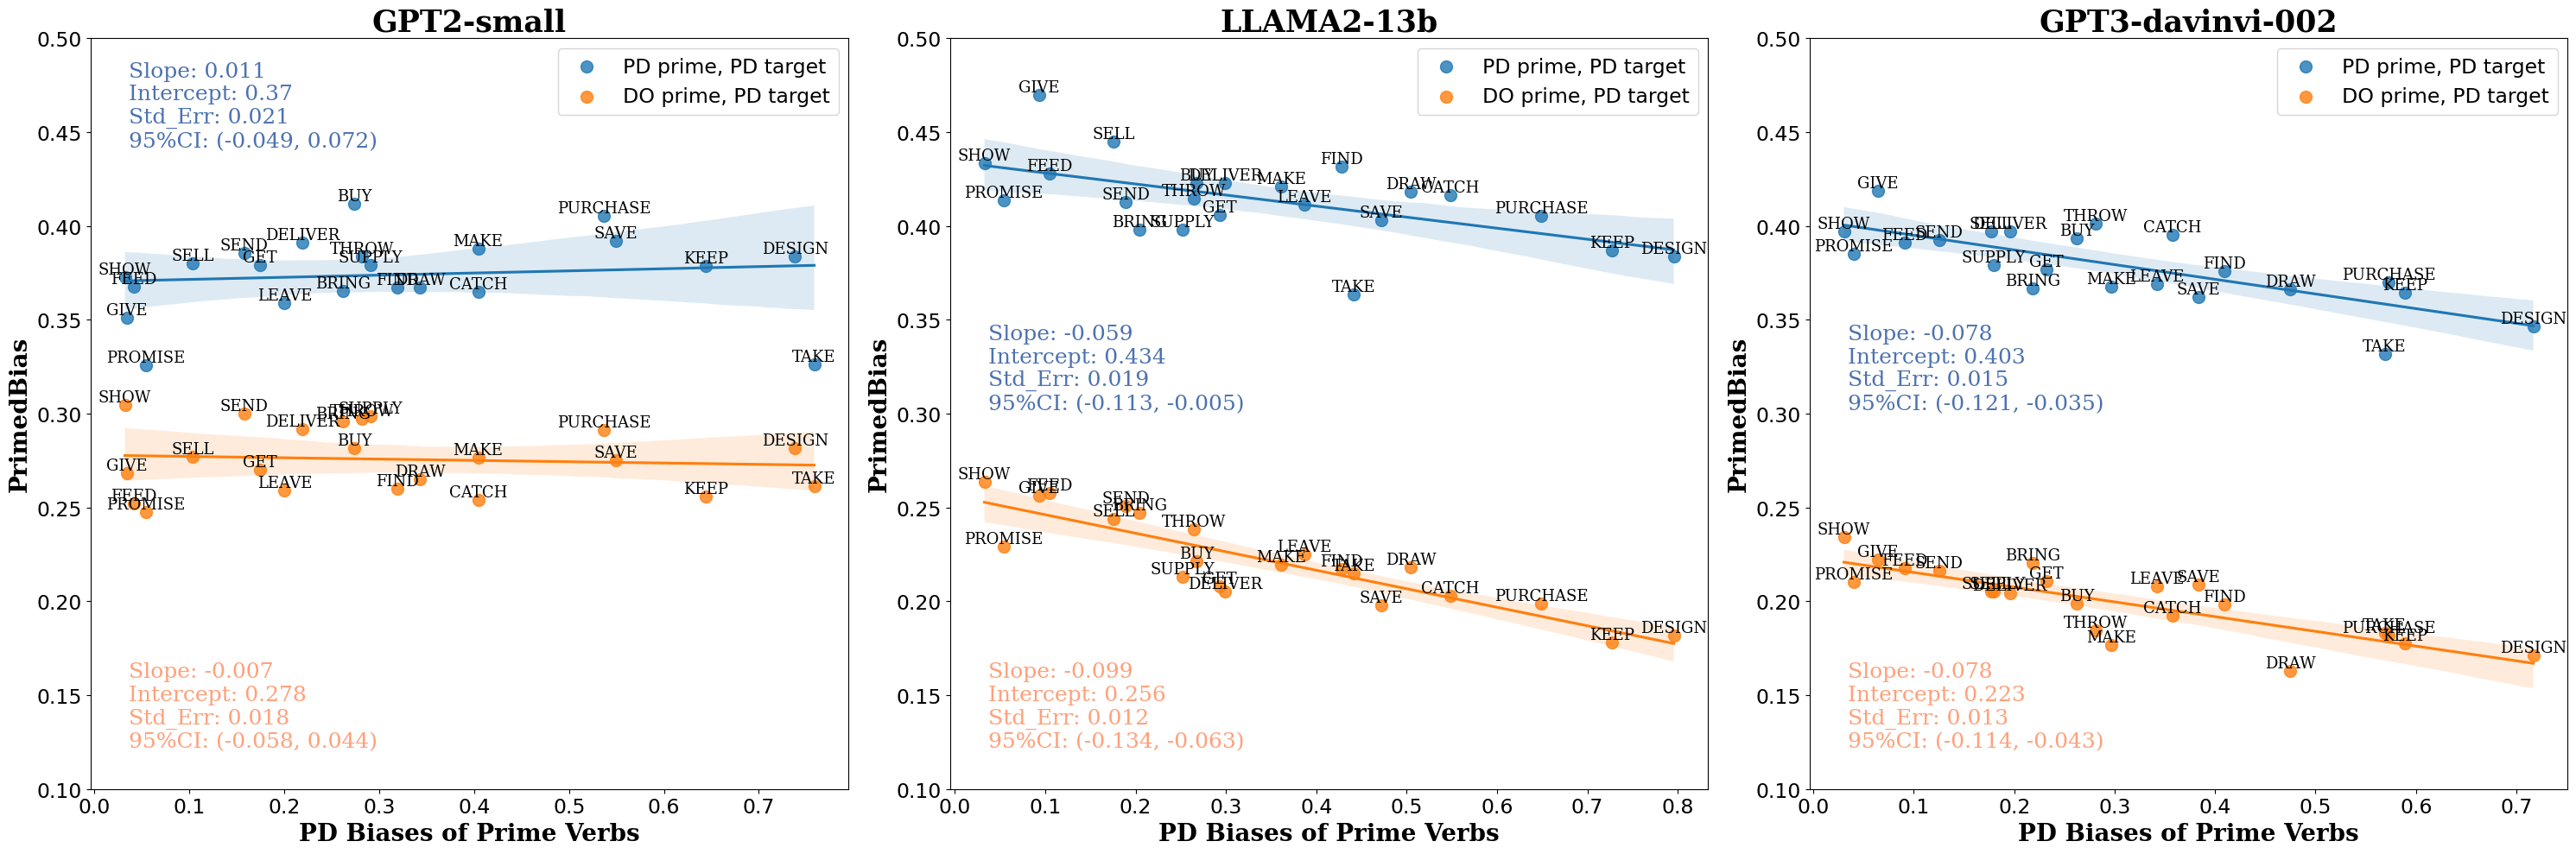

In [63]:
# Set figure size
fig, axes = plt.subplots(1, 3, figsize=(30, 10))

data = pd.read_csv(f'{ROOT_DIR}/results/GPT2/IFE_GPT2.csv')
stats = pd.read_csv(f'{ROOT_DIR}/results/GPT2/IFE_GPT2_Stats.csv')
SIZE = 'small'
PRONOUN = True
stats = stats[(stats['size'] == SIZE) & (stats['pronoun'] == PRONOUN)]
stats = stats.round(3)
file_pronoun = 'WithPronoun' if PRONOUN else 'NoPronoun'
df = data[(data['size'] == SIZE) & (data['pronoun'] == PRONOUN)]

data_PD = pd.DataFrame({'x': df['pd_bias'],
                    'y': df['PD-PD'],
                    'label': df['prime_verb'],
                    'legend': 'PD prime, PD target'})

data_DO = pd.DataFrame({'x': df['pd_bias'],
                    'y': df['DO-PD'],
                    'label': df['prime_verb'],
                    'legend': 'DO prime, PD target'})
ax = axes[0]

# Plot PD scatter plot
sns.regplot(x='x', y='y', data=data_PD, ax=ax, scatter_kws={"s": 100}, label=data_PD['legend'].iloc[0])
for i in range(len(data_PD)):
    ax.text(data_PD['x'].iloc[i], data_PD['y'].iloc[i], data_PD['label'].iloc[i], fontsize=13, ha='center', va='bottom', family='serif', style='normal', weight='light', color='black')

slope = stats['PD-PD_slope'].iloc[0]
intercept = stats['PD-PD_intercept'].iloc[0]
std_err = stats['PD-PD_std_err'].iloc[0]
CI = (stats['PD-PD_CI_lower'].iloc[0], stats['PD-PD_CI_upper'].iloc[0])


# Display slope and intercept
ax.text(0.05, 0.85, f"Slope: {slope}\nIntercept: {intercept}\nStd_Err: {std_err}\n95%CI: {CI}",
        transform=ax.transAxes, fontsize=18, ha='left', va='bottom', family='serif', style='normal', weight='normal', color='#4C72B0')

#####################################################################################################################################
# Plot DO scatter plot
sns.regplot(x='x', y='y', data=data_DO, ax=ax, scatter_kws={"s": 100}, label=data_DO['legend'].iloc[0])
for i in range(len(data_DO)):
    ax.text(data_DO['x'].iloc[i], data_DO['y'].iloc[i], data_DO['label'].iloc[i], fontsize=13, ha='center', va='bottom', family='serif', style='normal', weight='light', color='black')
    
slope = stats['DO-PD_slope'].iloc[0]
intercept = stats['DO-PD_intercept'].iloc[0]
std_err = stats['DO-PD_std_err'].iloc[0]
CI = (stats['DO-PD_CI_lower'].iloc[0], stats['DO-PD_CI_upper'].iloc[0])

# Display slope and intercept
ax.text(0.05, 0.05, f"Slope: {slope}\nIntercept: {intercept}\nStd_Err: {std_err}\n95%CI: {CI}",
        transform=ax.transAxes, fontsize=18, ha='left', va='bottom', family='serif', style='normal', weight='normal', color='#FFA07A')


#####################################################################################################################################

ax.legend(prop={'size': 17})
ax.set_xlabel('PD Biases of Prime Verbs', family='serif', style='normal', weight='bold', fontsize=20)
ax.set_ylabel('PrimedBias', family='serif', style='normal', weight='bold', fontsize=20)
ax.set_title('GPT2-small', family='serif', style='normal', weight='bold', fontsize=25)
ax.set_ylim(0.1, 0.5)
#ax.set_xlim(0, 0.8)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=17)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=17)






data = pd.read_csv(f'{ROOT_DIR}/results/Llama/IFE_Llama.csv')
stats = pd.read_csv(f'{ROOT_DIR}/results/Llama/IFE_Llama_Stats.csv')
SIZE = '13b'
PRONOUN = True
stats = stats[(stats['size'] == SIZE) & (stats['pronoun'] == PRONOUN)]
stats = stats.round(3)
file_pronoun = 'WithPronoun' if PRONOUN else 'NoPronoun'
df = data[(data['size'] == SIZE) & (data['pronoun'] == PRONOUN)]

data_PD = pd.DataFrame({'x': df['pd_bias'],
                    'y': df['PD-PD'],
                    'label': df['prime_verb'],
                    'legend': 'PD prime, PD target'})

data_DO = pd.DataFrame({'x': df['pd_bias'],
                    'y': df['DO-PD'],
                    'label': df['prime_verb'],
                    'legend': 'DO prime, PD target'})
ax = axes[1]

# Plot PD scatter plot
sns.regplot(x='x', y='y', data=data_PD, ax=ax, scatter_kws={"s": 100}, label=data_PD['legend'].iloc[0])
for i in range(len(data_PD)):
    ax.text(data_PD['x'].iloc[i], data_PD['y'].iloc[i], data_PD['label'].iloc[i], fontsize=13, ha='center', va='bottom', family='serif', style='normal', weight='light', color='black')
    
slope = stats['PD-PD_slope'].iloc[0]
intercept = stats['PD-PD_intercept'].iloc[0]
std_err = stats['PD-PD_std_err'].iloc[0]
CI = (stats['PD-PD_CI_lower'].iloc[0], stats['PD-PD_CI_upper'].iloc[0])

# Display slope and intercept
ax.text(0.05, 0.5, f"Slope: {slope}\nIntercept: {intercept}\nStd_Err: {std_err}\n95%CI: {CI}",
        transform=ax.transAxes, fontsize=18, ha='left', va='bottom', family='serif', style='normal', weight='normal', color='#4C72B0')

#####################################################################################################################################
# Plot DO scatter plot
sns.regplot(x='x', y='y', data=data_DO, ax=ax, scatter_kws={"s": 100}, label=data_DO['legend'].iloc[0])
for i in range(len(data_DO)):
    ax.text(data_DO['x'].iloc[i], data_DO['y'].iloc[i], data_DO['label'].iloc[i], fontsize=13, ha='center', va='bottom', family='serif', style='normal', weight='light', color='black')
    
slope = stats['DO-PD_slope'].iloc[0]
intercept = stats['DO-PD_intercept'].iloc[0]
std_err = stats['DO-PD_std_err'].iloc[0]
CI = (stats['DO-PD_CI_lower'].iloc[0], stats['DO-PD_CI_upper'].iloc[0])

# Display slope and intercept
ax.text(0.05, 0.05, f"Slope: {slope}\nIntercept: {intercept}\nStd_Err: {std_err}\n95%CI: {CI}",
        transform=ax.transAxes, fontsize=18, ha='left', va='bottom', family='serif', style='normal', weight='normal', color='#FFA07A')


#####################################################################################################################################

ax.legend(prop={'size': 17})
ax.set_xlabel('PD Biases of Prime Verbs', family='serif', style='normal', weight='bold', fontsize=20)
ax.set_ylabel('PrimedBias', family='serif', style='normal', weight='bold', fontsize=20)
ax.set_title('LLAMA2-13b', family='serif', style='normal', weight='bold', fontsize=25)
ax.set_ylim(0.1, 0.5)
#ax.set_xlim(0, 0.8)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=17)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=17)





data = pd.read_csv(f'{ROOT_DIR}/results/GPT3/IFE_GPT3.csv')
stats = pd.read_csv(f'{ROOT_DIR}/results/GPT3/IFE_GPT3_Stats.csv')
SIZE = 'davinci-002'
PRONOUN = True
stats = stats[(stats['size'] == SIZE) & (stats['pronoun'] == PRONOUN)]
stats = stats.round(3)
file_pronoun = 'WithPronoun' if PRONOUN else 'NoPronoun'
df = data[(data['size'] == SIZE) & (data['pronoun'] == PRONOUN)]

data_PD = pd.DataFrame({'x': df['pd_bias'],
                    'y': df['PD-PD'],
                    'label': df['prime_verb'],
                    'legend': 'PD prime, PD target'})

data_DO = pd.DataFrame({'x': df['pd_bias'],
                    'y': df['DO-PD'],
                    'label': df['prime_verb'],
                    'legend': 'DO prime, PD target'})
ax = axes[2]
# Plot PD scatter plot
sns.regplot(x='x', y='y', data=data_PD, ax=ax, scatter_kws={"s": 100}, label=data_PD['legend'].iloc[0])
for i in range(len(data_PD)):
    ax.text(data_PD['x'].iloc[i], data_PD['y'].iloc[i], data_PD['label'].iloc[i], fontsize=13, ha='center', va='bottom', family='serif', style='normal', weight='light', color='black')
    
slope = stats['PD-PD_slope'].iloc[0]
intercept = stats['PD-PD_intercept'].iloc[0]
std_err = stats['PD-PD_std_err'].iloc[0]
CI = (stats['PD-PD_CI_lower'].iloc[0], stats['PD-PD_CI_upper'].iloc[0])

# Display slope and intercept
ax.text(0.05, 0.5, f"Slope: {slope}\nIntercept: {intercept}\nStd_Err: {std_err}\n95%CI: {CI}",
        transform=ax.transAxes, fontsize=18, ha='left', va='bottom', family='serif', style='normal', weight='normal', color='#4C72B0')

#####################################################################################################################################
# Plot DO scatter plot
sns.regplot(x='x', y='y', data=data_DO, ax=ax, scatter_kws={"s": 100}, label=data_DO['legend'].iloc[0])
for i in range(len(data_DO)):
    ax.text(data_DO['x'].iloc[i], data_DO['y'].iloc[i], data_DO['label'].iloc[i], fontsize=13, ha='center', va='bottom', family='serif', style='normal', weight='light', color='black')
    
slope = stats['DO-PD_slope'].iloc[0]
intercept = stats['DO-PD_intercept'].iloc[0]
std_err = stats['DO-PD_std_err'].iloc[0]
CI = (stats['DO-PD_CI_lower'].iloc[0], stats['DO-PD_CI_upper'].iloc[0])

# Display slope and intercept
ax.text(0.05, 0.05, f"Slope: {slope}\nIntercept: {intercept}\nStd_Err: {std_err}\n95%CI: {CI}",
        transform=ax.transAxes, fontsize=18, ha='left', va='bottom', family='serif', style='normal', weight='normal', color='#FFA07A')


#####################################################################################################################################

ax.legend(prop={'size': 17})
ax.set_xlabel('PD Biases of Prime Verbs', family='serif', style='normal', weight='bold', fontsize=20)
ax.set_ylabel('PrimedBias', family='serif', style='normal', weight='bold', fontsize=20)
ax.set_title('GPT3-davinvi-002', family='serif', style='normal', weight='bold', fontsize=25)
ax.set_ylim(0.1, 0.5)
#ax.set_xlim(0, 0.8)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=17)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=17)


plt.tight_layout()

#fig.suptitle(f'Inverse Frequency Effect With Pronoun', family='serif', style='normal', weight='bold', fontsize=20)
plt.savefig(f'{ROOT_DIR}/plots/in_paper/Concatenation IFE Updated.png')
plt.show()

### Original

/var/folders/rd/jz160lxn3g5bc3cyzjv46lmr0000gp/T/ipykernel_40461/1871763058.py:66: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=17)
/var/folders/rd/jz160lxn3g5bc3cyzjv46lmr0000gp/T/ipykernel_40461/1871763058.py:67: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=17)
/var/folders/rd/jz160lxn3g5bc3cyzjv46lmr0000gp/T/ipykernel_40461/1871763058.py:136: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=17)
/var/folders/rd/jz160lxn3g5bc3cyzjv46lmr0000gp/T/ipykernel_40461/1871763058.py:137: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=17)
/var/folders/rd/jz160lxn3g5bc3cyzjv46lmr0000gp/T/ipykernel_40461/1871763058.py:204: UserWarning: FixedFormatter should only be used together w

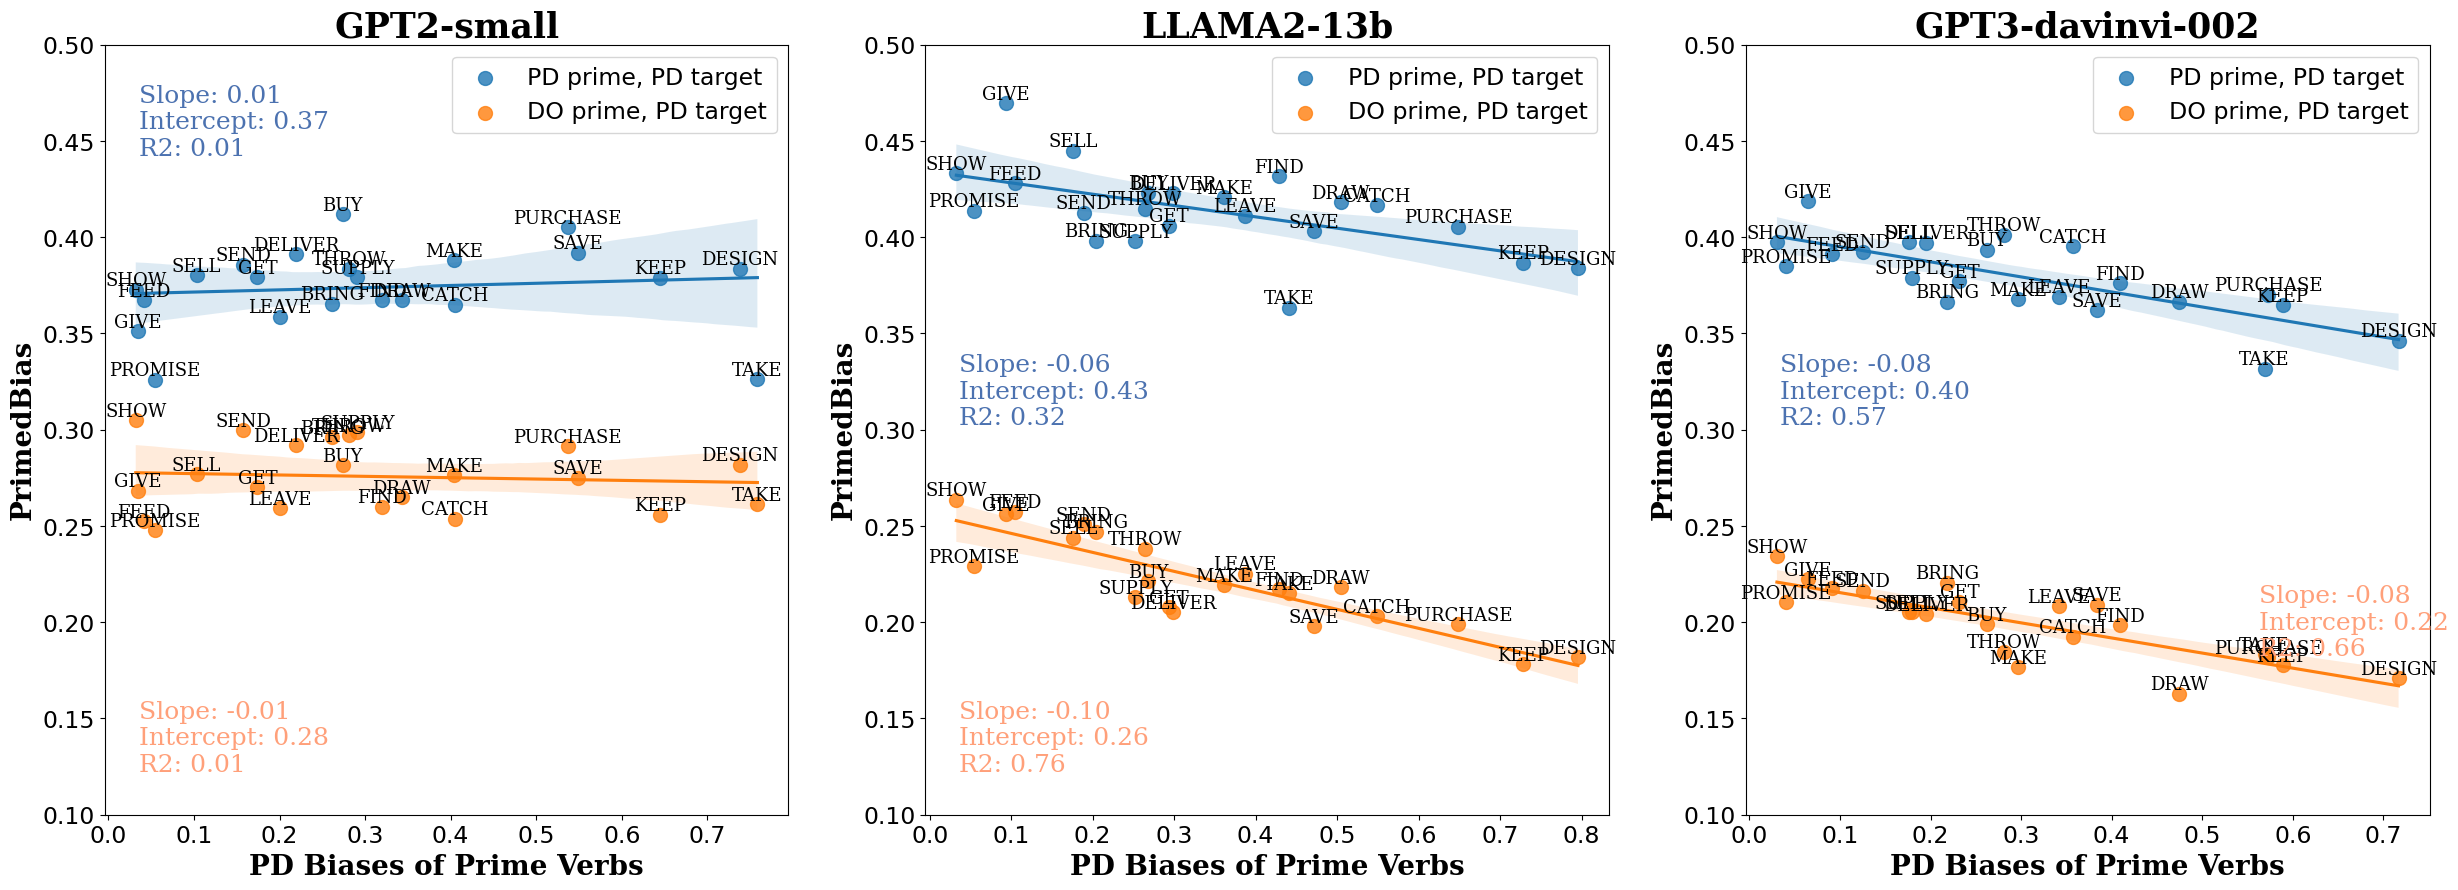

In [27]:
# Set figure size
fig, axes = plt.subplots(1, 3, figsize=(30, 10))

data = pd.read_csv(f'{ROOT_DIR}/results/GPT2/IFE_GPT2.csv')
stats = pd.read_csv(f'{ROOT_DIR}/results/GPT2/IFE_GPT2_Stats.csv')
SIZE = 'small'
PRONOUN = True
stats = stats[(stats['size'] == SIZE) & (stats['pronoun'] == PRONOUN)]
stats = stats.round(3)
file_pronoun = 'WithPronoun' if PRONOUN else 'NoPronoun'
df = data[(data['size'] == SIZE) & (data['pronoun'] == PRONOUN)]

data_PD = pd.DataFrame({'x': df['pd_bias'],
                    'y': df['PD-PD'],
                    'label': df['prime_verb'],
                    'legend': 'PD prime, PD target'})

data_DO = pd.DataFrame({'x': df['pd_bias'],
                    'y': df['DO-PD'],
                    'label': df['prime_verb'],
                    'legend': 'DO prime, PD target'})
ax = axes[0]

# Plot PD scatter plot
sns.regplot(x='x', y='y', data=data_PD, ax=ax, scatter_kws={"s": 100}, label=data_PD['legend'].iloc[0])
for i in range(len(data_PD)):
    ax.text(data_PD['x'].iloc[i], data_PD['y'].iloc[i], data_PD['label'].iloc[i], fontsize=13, ha='center', va='bottom', family='serif', style='normal', weight='light', color='black')
    
# Fit a line (perform linear regression)
# coefficients = np.polyfit(df['pd_bias'], data_PD['y'], 1)
slope = stats['PD-PD_slope'].iloc[0]
intercept = stats['PD-PD_intercept'].iloc[0]
CI = (stats['PD-PD_CI_lower'].iloc[0], stats['PD-PD_CI_upper'].iloc[0])
# poly = np.poly1d(coefficients)
# y_pred = poly(df['pd_bias']) # Calculate the predicted values (y_pred)
# r_squared = r2_score(data_PD['y'], y_pred) # Calculate R-squared value
# rmse = np.sqrt(mean_squared_error(data_PD['y'], y_pred)) # Calculate Root Mean Squared Error (RMSE)

# Display slope and intercept
ax.text(0.05, 0.85, f"Slope: {slope:.2f}\nIntercept: {intercept:.2f}\nR2: {r_squared:.2f}",
        transform=ax.transAxes, fontsize=18, ha='left', va='bottom', family='serif', style='normal', weight='normal', color='#4C72B0')

#####################################################################################################################################
# Plot DO scatter plot
sns.regplot(x='x', y='y', data=data_DO, ax=ax, scatter_kws={"s": 100}, label=data_DO['legend'].iloc[0])
for i in range(len(data_DO)):
    ax.text(data_DO['x'].iloc[i], data_DO['y'].iloc[i], data_DO['label'].iloc[i], fontsize=13, ha='center', va='bottom', family='serif', style='normal', weight='light', color='black')
    
# Fit a line (perform linear regression)
coefficients = np.polyfit(df['pd_bias'], data_DO['y'], 1)
slope = coefficients[0]
intercept = coefficients[1]
poly = np.poly1d(coefficients)
y_pred = poly(df['pd_bias']) # Calculate the predicted values (y_pred)
r_squared = r2_score(data_DO['y'], y_pred) # Calculate R-squared value
#rmse = np.sqrt(mean_squared_error(data_DO['y'], y_pred)) # Calculate Root Mean Squared Error (RMSE)

# Display slope and intercept
ax.text(0.05, 0.05, f"Slope: {slope:.2f}\nIntercept: {intercept:.2f}\nR2: {r_squared:.2f}",
        transform=ax.transAxes, fontsize=18, ha='left', va='bottom', family='serif', style='normal', weight='normal', color='#FFA07A')


#####################################################################################################################################

ax.legend(prop={'size': 17})
ax.set_xlabel('PD Biases of Prime Verbs', family='serif', style='normal', weight='bold', fontsize=20)
ax.set_ylabel('PrimedBias', family='serif', style='normal', weight='bold', fontsize=20)
ax.set_title('GPT2-small', family='serif', style='normal', weight='bold', fontsize=25)
ax.set_ylim(0.1, 0.5)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=17)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=17)






data = pd.read_csv(f'{ROOT_DIR}/results/Llama/IFE_Llama.csv')
stats = pd.read_csv(f'{ROOT_DIR}/results/Llama/IFE_Llama_Stats.csv')
SIZE = '13b'
PRONOUN = True
file_pronoun = 'WithPronoun' if PRONOUN else 'NoPronoun'
df = data[(data['size'] == SIZE) & (data['pronoun'] == PRONOUN)]

data_PD = pd.DataFrame({'x': df['pd_bias'],
                    'y': df['PD-PD'],
                    'label': df['prime_verb'],
                    'legend': 'PD prime, PD target'})

data_DO = pd.DataFrame({'x': df['pd_bias'],
                    'y': df['DO-PD'],
                    'label': df['prime_verb'],
                    'legend': 'DO prime, PD target'})
ax = axes[1]

# Plot PD scatter plot
sns.regplot(x='x', y='y', data=data_PD, ax=ax, scatter_kws={"s": 100}, label=data_PD['legend'].iloc[0])
for i in range(len(data_PD)):
    ax.text(data_PD['x'].iloc[i], data_PD['y'].iloc[i], data_PD['label'].iloc[i], fontsize=13, ha='center', va='bottom', family='serif', style='normal', weight='light', color='black')
    
# Fit a line (perform linear regression)
coefficients = np.polyfit(df['pd_bias'], data_PD['y'], 1)
slope = coefficients[0]
intercept = coefficients[1]
poly = np.poly1d(coefficients)
y_pred = poly(df['pd_bias']) # Calculate the predicted values (y_pred)
r_squared = r2_score(data_PD['y'], y_pred) # Calculate R-squared value
#rmse = np.sqrt(mean_squared_error(data_PD['y'], y_pred)) # Calculate Root Mean Squared Error (RMSE)

# Display slope and intercept
ax.text(0.05, 0.5, f"Slope: {slope:.2f}\nIntercept: {intercept:.2f}\nR2: {r_squared:.2f}",
        transform=ax.transAxes, fontsize=18, ha='left', va='bottom', family='serif', style='normal', weight='normal', color='#4C72B0')

#####################################################################################################################################
# Plot DO scatter plot
sns.regplot(x='x', y='y', data=data_DO, ax=ax, scatter_kws={"s": 100}, label=data_DO['legend'].iloc[0])
for i in range(len(data_DO)):
    ax.text(data_DO['x'].iloc[i], data_DO['y'].iloc[i], data_DO['label'].iloc[i], fontsize=13, ha='center', va='bottom', family='serif', style='normal', weight='light', color='black')
    
# Fit a line (perform linear regression)
coefficients = np.polyfit(df['pd_bias'], data_DO['y'], 1)
slope = coefficients[0]
intercept = coefficients[1]
poly = np.poly1d(coefficients)
y_pred = poly(df['pd_bias']) # Calculate the predicted values (y_pred)
r_squared = r2_score(data_DO['y'], y_pred) # Calculate R-squared value
#rmse = np.sqrt(mean_squared_error(data_DO['y'], y_pred)) # Calculate Root Mean Squared Error (RMSE)

# Display slope and intercept
ax.text(0.05, 0.05, f"Slope: {slope:.2f}\nIntercept: {intercept:.2f}\nR2: {r_squared:.2f}",
        transform=ax.transAxes, fontsize=18, ha='left', va='bottom', family='serif', style='normal', weight='normal', color='#FFA07A')


#####################################################################################################################################

ax.legend(prop={'size': 17})
ax.set_xlabel('PD Biases of Prime Verbs', family='serif', style='normal', weight='bold', fontsize=20)
ax.set_ylabel('PrimedBias', family='serif', style='normal', weight='bold', fontsize=20)
ax.set_title('LLAMA2-13b', family='serif', style='normal', weight='bold', fontsize=25)
ax.set_ylim(0.1, 0.5)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=17)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=17)





data = pd.read_csv(f'{ROOT_DIR}/results/GPT3/IFE_GPT3.csv')
stats = pd.read_csv(f'{ROOT_DIR}/results/GPT3/IFE_GPT3_Stats.csv')
SIZE = 'davinci-002'
PRONOUN = True
file_pronoun = 'WithPronoun' if PRONOUN else 'NoPronoun'
df = data[(data['size'] == SIZE) & (data['pronoun'] == PRONOUN)]

data_PD = pd.DataFrame({'x': df['pd_bias'],
                    'y': df['PD-PD'],
                    'label': df['prime_verb'],
                    'legend': 'PD prime, PD target'})

data_DO = pd.DataFrame({'x': df['pd_bias'],
                    'y': df['DO-PD'],
                    'label': df['prime_verb'],
                    'legend': 'DO prime, PD target'})
ax = axes[2]
# Plot PD scatter plot
sns.regplot(x='x', y='y', data=data_PD, ax=ax, scatter_kws={"s": 100}, label=data_PD['legend'].iloc[0])
for i in range(len(data_PD)):
    ax.text(data_PD['x'].iloc[i], data_PD['y'].iloc[i], data_PD['label'].iloc[i], fontsize=13, ha='center', va='bottom', family='serif', style='normal', weight='light', color='black')
    
# Fit a line (perform linear regression)
coefficients = np.polyfit(df['pd_bias'], data_PD['y'], 1)
slope = coefficients[0]
intercept = coefficients[1]
poly = np.poly1d(coefficients)
y_pred = poly(df['pd_bias']) # Calculate the predicted values (y_pred)
r_squared = r2_score(data_PD['y'], y_pred) # Calculate R-squared value
#rmse = np.sqrt(mean_squared_error(data_PD['y'], y_pred)) # Calculate Root Mean Squared Error (RMSE)

# Display slope and intercept
ax.text(0.05, 0.5, f"Slope: {slope:.2f}\nIntercept: {intercept:.2f}\nR2: {r_squared:.2f}",
        transform=ax.transAxes, fontsize=18, ha='left', va='bottom', family='serif', style='normal', weight='normal', color='#4C72B0')

#####################################################################################################################################
# Plot DO scatter plot
sns.regplot(x='x', y='y', data=data_DO, ax=ax, scatter_kws={"s": 100}, label=data_DO['legend'].iloc[0])
for i in range(len(data_DO)):
    ax.text(data_DO['x'].iloc[i], data_DO['y'].iloc[i], data_DO['label'].iloc[i], fontsize=13, ha='center', va='bottom', family='serif', style='normal', weight='light', color='black')
    
# Fit a line (perform linear regression)
coefficients = np.polyfit(df['pd_bias'], data_DO['y'], 1)
slope = coefficients[0]
intercept = coefficients[1]
poly = np.poly1d(coefficients)
y_pred = poly(df['pd_bias']) # Calculate the predicted values (y_pred)
r_squared = r2_score(data_DO['y'], y_pred) # Calculate R-squared value
#rmse = np.sqrt(mean_squared_error(data_DO['y'], y_pred)) # Calculate Root Mean Squared Error (RMSE)

# Display slope and intercept
ax.text(0.75, 0.2, f"Slope: {slope:.2f}\nIntercept: {intercept:.2f}\nR2: {r_squared:.2f}",
        transform=ax.transAxes, fontsize=18, ha='left', va='bottom', family='serif', style='normal', weight='normal', color='#FFA07A')


#####################################################################################################################################

ax.legend(prop={'size': 17})
ax.set_xlabel('PD Biases of Prime Verbs', family='serif', style='normal', weight='bold', fontsize=20)
ax.set_ylabel('PrimedBias', family='serif', style='normal', weight='bold', fontsize=20)
ax.set_title('GPT3-davinvi-002', family='serif', style='normal', weight='bold', fontsize=25)
ax.set_ylim(0.1, 0.5)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=17)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=17)


#plt.tight_layout()

#fig.suptitle(f'Inverse Frequency Effect With Pronoun', family='serif', style='normal', weight='bold', fontsize=20)
# plt.savefig(f'{ROOT_DIR}/plots/in_paper/Concatenation IFE Updated.png')
plt.show()

# FT IFE Plot

In [3]:
data = pd.read_csv(f'{ROOT_DIR}/results/FT/IFE_FT.csv')
stats = pd.read_csv(f'{ROOT_DIR}/results/FT/IFE_FT_Stats.csv')
SIZE = 'small'
PRONOUN = True
SQUARED = False
stats = stats[(stats['size'] == SIZE) & (stats['pronoun'] == PRONOUN) & (stats['squared'] == SQUARED)]
stats = stats.round(3)
file_pronoun = 'WithPronoun' if PRONOUN else 'NoPronoun'
df = data[(data['size'] == SIZE) & (data['pronoun'] == PRONOUN) & (data['squared'] == SQUARED)]
stats

,size,squared,pronoun,PD-PD_slope,PD-PD_intercept,PD-PD_std_err,PD-PD_CI_lower,PD-PD_CI_upper,PD-PD_r_value,PD-PD_p_value,...,PD-PD_RMSE,DO-PD_slope,DO-PD_intercept,DO-PD_std_err,DO-PD_CI_lower,DO-PD_CI_upper,DO-PD_r_value,DO-PD_p_value,DO-PD_R2,DO-PD_RMSE
0,small,False,True,-0.048,0.452,0.021,-0.107,0.012,-0.455,0.033,...,0.02,-0.117,0.268,0.014,-0.157,-0.077,-0.88,0.0,0.775,0.014


/var/folders/rd/jz160lxn3g5bc3cyzjv46lmr0000gp/T/ipykernel_59620/2852672652.py:63: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=17)
/var/folders/rd/jz160lxn3g5bc3cyzjv46lmr0000gp/T/ipykernel_59620/2852672652.py:64: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=17)
/var/folders/rd/jz160lxn3g5bc3cyzjv46lmr0000gp/T/ipykernel_59620/2852672652.py:129: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=17)
/var/folders/rd/jz160lxn3g5bc3cyzjv46lmr0000gp/T/ipykernel_59620/2852672652.py:130: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=17)


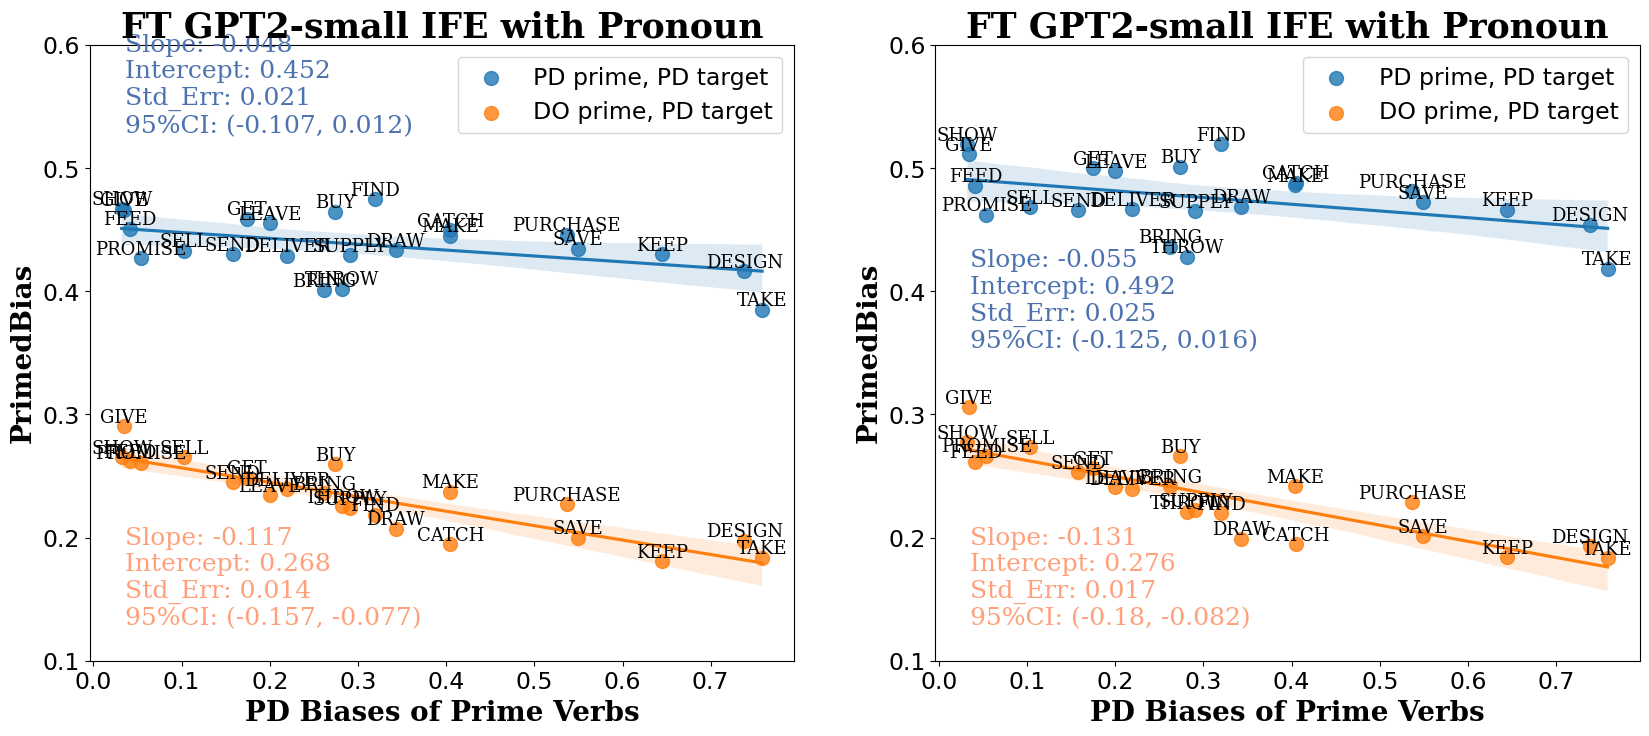

In [7]:
# Set figure size
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

data = pd.read_csv(f'{ROOT_DIR}/results/FT/IFE_FT.csv')
stats = pd.read_csv(f'{ROOT_DIR}/results/FT/IFE_FT_Stats.csv')
SIZE = 'small'
PRONOUN = True
SQUARED = False
stats = stats[(stats['size'] == SIZE) & (stats['pronoun'] == PRONOUN) & (stats['squared'] == SQUARED)]
stats = stats.round(3)
file_pronoun = 'WithPronoun' if PRONOUN else 'NoPronoun'
df = data[(data['size'] == SIZE) & (data['pronoun'] == PRONOUN) & (data['squared'] == SQUARED)]

data_PD = pd.DataFrame({'x': df['pd_bias'],
                    'y': df['PD-PD'],
                    'label': df['prime_verb'],
                    'legend': 'PD prime, PD target'})

data_DO = pd.DataFrame({'x': df['pd_bias'],
                    'y': df['DO-PD'],
                    'label': df['prime_verb'],
                    'legend': 'DO prime, PD target'})
ax = axes[0]

# Plot PD scatter plot
sns.regplot(x='x', y='y', data=data_PD, ax=ax, scatter_kws={"s": 100}, label=data_PD['legend'].iloc[0])
for i in range(len(data_PD)):
    ax.text(data_PD['x'].iloc[i], data_PD['y'].iloc[i], data_PD['label'].iloc[i], fontsize=13, ha='center', va='bottom', family='serif', style='normal', weight='light', color='black')

slope = stats['PD-PD_slope'].iloc[0]
intercept = stats['PD-PD_intercept'].iloc[0]
std_err = stats['PD-PD_std_err'].iloc[0]
CI = (stats['PD-PD_CI_lower'].iloc[0], stats['PD-PD_CI_upper'].iloc[0])


# Display slope and intercept
ax.text(0.05, 0.85, f"Slope: {slope}\nIntercept: {intercept}\nStd_Err: {std_err}\n95%CI: {CI}",
        transform=ax.transAxes, fontsize=18, ha='left', va='bottom', family='serif', style='normal', weight='normal', color='#4C72B0')

#####################################################################################################################################
# Plot DO scatter plot
sns.regplot(x='x', y='y', data=data_DO, ax=ax, scatter_kws={"s": 100}, label=data_DO['legend'].iloc[0])
for i in range(len(data_DO)):
    ax.text(data_DO['x'].iloc[i], data_DO['y'].iloc[i], data_DO['label'].iloc[i], fontsize=13, ha='center', va='bottom', family='serif', style='normal', weight='light', color='black')
    
slope = stats['DO-PD_slope'].iloc[0]
intercept = stats['DO-PD_intercept'].iloc[0]
std_err = stats['DO-PD_std_err'].iloc[0]
CI = (stats['DO-PD_CI_lower'].iloc[0], stats['DO-PD_CI_upper'].iloc[0])

# Display slope and intercept
ax.text(0.05, 0.05, f"Slope: {slope}\nIntercept: {intercept}\nStd_Err: {std_err}\n95%CI: {CI}",
        transform=ax.transAxes, fontsize=18, ha='left', va='bottom', family='serif', style='normal', weight='normal', color='#FFA07A')


#####################################################################################################################################

ax.legend(prop={'size': 17})
ax.set_xlabel('PD Biases of Prime Verbs', family='serif', style='normal', weight='bold', fontsize=20)
ax.set_ylabel('PrimedBias', family='serif', style='normal', weight='bold', fontsize=20)
ax.set_title('FT GPT2-small IFE with Pronoun', family='serif', style='normal', weight='bold', fontsize=25)
ax.set_ylim(0.1, 0.6)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=17)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=17)






data = pd.read_csv(f'{ROOT_DIR}/results/FT/IFE_FT.csv')
stats = pd.read_csv(f'{ROOT_DIR}/results/FT/IFE_FT_Stats.csv')
SIZE = 'small'
PRONOUN = True
SQUARED = True
stats = stats[(stats['size'] == SIZE) & (stats['pronoun'] == PRONOUN) & (stats['squared'] == SQUARED)]
stats = stats.round(3)
file_pronoun = 'WithPronoun' if PRONOUN else 'NoPronoun'
df = data[(data['size'] == SIZE) & (data['pronoun'] == PRONOUN) & (data['squared'] == SQUARED)]

data_PD = pd.DataFrame({'x': df['pd_bias'],
                    'y': df['PD-PD'],
                    'label': df['prime_verb'],
                    'legend': 'PD prime, PD target'})

data_DO = pd.DataFrame({'x': df['pd_bias'],
                    'y': df['DO-PD'],
                    'label': df['prime_verb'],
                    'legend': 'DO prime, PD target'})
ax = axes[1]

# Plot PD scatter plot
sns.regplot(x='x', y='y', data=data_PD, ax=ax, scatter_kws={"s": 100}, label=data_PD['legend'].iloc[0])
for i in range(len(data_PD)):
    ax.text(data_PD['x'].iloc[i], data_PD['y'].iloc[i], data_PD['label'].iloc[i], fontsize=13, ha='center', va='bottom', family='serif', style='normal', weight='light', color='black')
    
slope = stats['PD-PD_slope'].iloc[0]
intercept = stats['PD-PD_intercept'].iloc[0]
std_err = stats['PD-PD_std_err'].iloc[0]
CI = (stats['PD-PD_CI_lower'].iloc[0], stats['PD-PD_CI_upper'].iloc[0])

# Display slope and intercept
ax.text(0.05, 0.5, f"Slope: {slope}\nIntercept: {intercept}\nStd_Err: {std_err}\n95%CI: {CI}",
        transform=ax.transAxes, fontsize=18, ha='left', va='bottom', family='serif', style='normal', weight='normal', color='#4C72B0')

#####################################################################################################################################
# Plot DO scatter plot
sns.regplot(x='x', y='y', data=data_DO, ax=ax, scatter_kws={"s": 100}, label=data_DO['legend'].iloc[0])
for i in range(len(data_DO)):
    ax.text(data_DO['x'].iloc[i], data_DO['y'].iloc[i], data_DO['label'].iloc[i], fontsize=13, ha='center', va='bottom', family='serif', style='normal', weight='light', color='black')
    
slope = stats['DO-PD_slope'].iloc[0]
intercept = stats['DO-PD_intercept'].iloc[0]
std_err = stats['DO-PD_std_err'].iloc[0]
CI = (stats['DO-PD_CI_lower'].iloc[0], stats['DO-PD_CI_upper'].iloc[0])

# Display slope and intercept
ax.text(0.05, 0.05, f"Slope: {slope}\nIntercept: {intercept}\nStd_Err: {std_err}\n95%CI: {CI}",
        transform=ax.transAxes, fontsize=18, ha='left', va='bottom', family='serif', style='normal', weight='normal', color='#FFA07A')


#####################################################################################################################################

ax.legend(prop={'size': 17})
ax.set_xlabel('PD Biases of Prime Verbs', family='serif', style='normal', weight='bold', fontsize=20)
ax.set_ylabel('PrimedBias', family='serif', style='normal', weight='bold', fontsize=20)
ax.set_title('FT GPT2-small IFE with Pronoun', family='serif', style='normal', weight='bold', fontsize=25)
ax.set_ylim(0.1, 0.6)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=17)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=17)






# plt.tight_layout()

#fig.suptitle(f'Inverse Frequency Effect With Pronoun', family='serif', style='normal', weight='bold', fontsize=20)
#plt.savefig(f'{ROOT_DIR}/plots/in_paper/Concatenation IFE Updated.png')
extent = axes[1].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
fig.savefig("right_subplot_with_labels.png", bbox_inches=extent.expanded(1.07, 1.07))
plt.show()